In [1]:
# Cell 1: Environment Setup - Install all dependencies properly
# Use compatible versions for Kaggle's environment

!pip install -q jaxtyping rich 
!pip install -q transformer-lens sae-lens einops
!pip install -q accelerate sentencepiece protobuf

import torch
import numpy as np
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass
import json
import random
import re
import urllib.request
import zipfile
import os

# Check versions
print(f"NumPy version: {np.__version__}")
print(f"PyTorch version: {torch.__version__}")

# Set seeds
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip
NumPy version: 2.3.3
PyTorch version: 2.8.0+cu128
Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
# Cell 2: Imports - should work now
from transformer_lens import HookedTransformer
from transformers import AutoTokenizer

print("All imports successful!")

/home/jay/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful!


In [3]:
# Cell 3: Data Pipeline - 100% Data-Driven, No Hardcoded Content

@dataclass
class TextCorpus:
    """Container for a text corpus with metadata"""
    name: str
    text: str
    tokens: Optional[torch.Tensor] = None
    num_tokens: int = 0
    
    def __post_init__(self):
        if self.tokens is not None:
            self.num_tokens = len(self.tokens)

class HPCorpusLoader:
    """Loads Harry Potter corpus from file"""
    
    def __init__(self, file_path: str = "/kaggle/input/Harry_Potter_all_books_preprocessed.txt"):
        self.file_path = Path(file_path)
        self.raw_text: Optional[str] = None
        self.corpus: Optional[TextCorpus] = None
        
    def load(self, sample_chars: Optional[int] = None) -> TextCorpus:
        """Load HP corpus from file system"""
        # Try multiple possible paths
        paths_to_try = [
            self.file_path,
            Path("./Harry_Potter_all_books_preprocessed.txt"),  
            Path("/kaggle/working/Harry_Potter_all_books_preprocessed.txt"),
            # Your uploaded file
        ]
        
        found_path = None
        for path in paths_to_try:
            if path.exists():
                found_path = path
                break
        
        if found_path is None:
            raise FileNotFoundError(
                f"Could not find HP corpus. Tried: {[str(p) for p in paths_to_try]}"
            )
        
        self.file_path = found_path
        print(f"Loading from: {self.file_path}")
        
        with open(self.file_path, 'r', encoding='utf-8') as f:
            self.raw_text = f.read()
            
        if sample_chars:
            self.raw_text = self.raw_text[:sample_chars]
            
        self.corpus = TextCorpus(
            name="harry_potter",
            text=self.raw_text
        )
        
        print(f"Loaded {len(self.raw_text):,} characters")
        return self.corpus
    
    def get_content_stats(self) -> Dict[str, any]:
        """Get basic statistics - data-driven"""
        assert self.raw_text is not None, "Load corpus first!"
        
        words = self.raw_text.split()
        
        stats = {
            'total_chars': len(self.raw_text),
            'total_words': len(words),
            'avg_word_length': sum(len(w) for w in words) / len(words) if words else 0,
            'sample_text': self.raw_text[:500]
        }
        
        # Find frequent capitalized words (potential proper nouns/entities)
        capitalized = []
        for word in words:
            clean = re.sub(r'[^\w]', '', word)
            if len(clean) > 3 and clean[0].isupper() and clean[1:].islower():
                capitalized.append(clean)
        
        from collections import Counter
        top_capitalized = Counter(capitalized).most_common(15)
        stats['frequent_capitalized_words'] = top_capitalized
        
        return stats
    
    def chunk_text(self, chunk_size: int = 512, overlap: int = 128) -> List[str]:
        """Split text into overlapping chunks"""
        assert self.raw_text is not None, "Load corpus first!"
        
        chunks = []
        start = 0
        while start < len(self.raw_text):
            end = start + chunk_size
            chunk = self.raw_text[start:end]
            if len(chunk) >= 100:  # Only keep substantial chunks
                chunks.append(chunk)
            start += (chunk_size - overlap)
            
        return chunks

class NeutralCorpusLoader:
    """
    Loads REAL neutral text from public sources.
    NO hardcoded/synthetic text - only downloaded real data.
    """
    
    def __init__(self, cache_dir: str = "./neutral_corpus_cache"):
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(exist_ok=True)
        self.corpus: Optional[TextCorpus] = None
        
    def load(self, target_chars: int = 500_000) -> TextCorpus:
        """
        Load neutral corpus from real text sources.
        Downloads sample texts from Project Gutenberg (public domain).
        """
        cache_file = self.cache_dir / "neutral_corpus.txt"
        
        # Use cached version if available
        if cache_file.exists():
            print(f"Loading cached neutral corpus from {cache_file}")
            with open(cache_file, 'r', encoding='utf-8') as f:
                text = f.read()
            self.corpus = TextCorpus(name="gutenberg_neutral", text=text[:target_chars])
            print(f"Loaded {len(self.corpus.text):,} characters")
            return self.corpus
        
        # Download real texts from Project Gutenberg
        print("Downloading neutral texts from Project Gutenberg...")
        
        # Public domain texts (diverse topics, definitely not HP)
        gutenberg_urls = [
            # Pride and Prejudice
            "https://www.gutenberg.org/files/1342/1342-0.txt",
            # Moby Dick  
            "https://www.gutenberg.org/files/2701/2701-0.txt",
            # Sherlock Holmes
            "https://www.gutenberg.org/files/1661/1661-0.txt",
            # Alice in Wonderland
            "https://www.gutenberg.org/files/11/11-0.txt",
            # Dracula
            "https://www.gutenberg.org/files/345/345-0.txt",
        ]
        
        all_texts = []
        total_chars = 0
        
        for url in gutenberg_urls:
            if total_chars >= target_chars * 1.5:  # Get extra to filter header/footer
                break
                
            try:
                print(f"  Downloading from {url.split('/')[-1]}...")
                
                # Download with proper headers
                req = urllib.request.Request(
                    url, 
                    headers={'User-Agent': 'Mozilla/5.0 (Academic Project)'}
                )
                
                with urllib.request.urlopen(req, timeout=30) as response:
                    raw_bytes = response.read()
                    text = raw_bytes.decode('utf-8', errors='ignore')
                    
                    # Strip Project Gutenberg header/footer
                    text = self._strip_gutenberg_boilerplate(text)
                    
                    if len(text) > 1000:  # Ensure we got actual content
                        all_texts.append(text)
                        total_chars += len(text)
                        print(f"    Got {len(text):,} chars")
                        
            except Exception as e:
                print(f"    Failed: {e}")
                continue
        
        if not all_texts:
            raise RuntimeError(
                "Could not download neutral texts. "
                "Please check internet connection or provide local neutral text file."
            )
        
        # Combine and shuffle sentences for diversity
        combined_text = self._shuffle_sentences("\n\n".join(all_texts))
        
        # Cache for future runs
        with open(cache_file, 'w', encoding='utf-8') as f:
            f.write(combined_text)
        
        self.corpus = TextCorpus(
            name="gutenberg_neutral",
            text=combined_text[:target_chars]
        )
        
        print(f"✓ Loaded {len(self.corpus.text):,} characters of real neutral text")
        return self.corpus
    
    def _strip_gutenberg_boilerplate(self, text: str) -> str:
        """Remove Project Gutenberg header and footer"""
        # Find start of actual content
        start_markers = [
            "*** START OF THE PROJECT GUTENBERG EBOOK",
            "*** START OF THIS PROJECT GUTENBERG EBOOK",
            "Produced by",
            "CHAPTER I",
        ]
        
        end_markers = [
            "*** END OF THE PROJECT GUTENBERG EBOOK",
            "*** END OF THIS PROJECT GUTENBERG EBOOK",
        ]
        
        start_idx = 0
        for marker in start_markers:
            idx = text.find(marker)
            if idx != -1:
                start_idx = text.find("\n", idx) + 1
                break
        
        end_idx = len(text)
        for marker in end_markers:
            idx = text.find(marker)
            if idx != -1:
                end_idx = idx
                break
        
        return text[start_idx:end_idx].strip()
    
    def _shuffle_sentences(self, text: str) -> str:
        """Shuffle sentences to break narrative flow and increase diversity"""
        sentences = re.split(r'(?<=[.!?])\s+', text)
        sentences = [s.strip() for s in sentences if len(s.strip()) > 20]
        
        # Shuffle in chunks to maintain some coherence but increase variety
        chunk_size = 10
        shuffled = []
        for i in range(0, len(sentences), chunk_size):
            chunk = sentences[i:i+chunk_size]
            random.shuffle(chunk)
            shuffled.extend(chunk)
            
        return " ".join(shuffled)

class TokenizedCorpus:
    """Tokenizes corpora for model consumption"""
    
    def __init__(self, model_name: str = "gpt2"):
        print(f"Loading tokenizer: {model_name}")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.tokenizer.pad_token = self.tokenizer.eos_token
        
    def tokenize_corpus(self, corpus: TextCorpus, max_length: int = 512) -> TextCorpus:
        """Tokenize text corpus"""
        print(f"Tokenizing {corpus.name}...")
        
        # Process in manageable chunks
        chunk_size = 10000
        tokens_list = []
        
        for i in range(0, len(corpus.text), chunk_size):
            chunk = corpus.text[i:i+chunk_size]
            encoded = self.tokenizer(
                chunk,
                return_tensors="pt",
                truncation=True,
                max_length=max_length,
                padding=False
            )
            # Ensure 1D tensor
            if encoded['input_ids'].dim() > 1:
                t = encoded['input_ids'].squeeze(0)
            else:
                t = encoded['input_ids']
            tokens_list.append(t)
        
        all_tokens = torch.cat(tokens_list)
        
        corpus.tokens = all_tokens
        corpus.num_tokens = len(all_tokens)
        
        print(f"Tokenized to {corpus.num_tokens:,} tokens")
        return corpus
    
    def get_token_batches(self, corpus: TextCorpus, batch_size: int = 512, 
                         stride: Optional[int] = None) -> torch.Tensor:
        """Get sliding windows of tokens"""
        if stride is None:
            stride = batch_size
            
        tokens = corpus.tokens
        windows = []
        
        for start in range(0, len(tokens) - batch_size + 1, stride):
            window = tokens[start:start + batch_size]
            if len(window) == batch_size:  # Only complete windows
                windows.append(window)
        
        if not windows:
            return torch.tensor([])
            
        return torch.stack(windows)

In [4]:
# Cell 4: Unit Tests

def test_hp_corpus():
    """Test HP corpus loading"""
    print("="*60)
    print("TEST 1: HP Corpus Loading")
    print("="*60)
    
    loader = HPCorpusLoader()
    
    # Test with sample
    corpus = loader.load(sample_chars=50000)
    
    assert corpus is not None
    print(f"✓ Loaded {len(corpus.text):,} characters")
    
    # Data-driven stats
    stats = loader.get_content_stats()
    print(f"\nMost frequent capitalized words:")
    for word, count in stats['frequent_capitalized_words'][:10]:
        print(f"  {word}: {count}")
    
    # Verify actual content
    assert stats['total_words'] > 5000
    
    return loader

def test_neutral_corpus():
    """Test neutral corpus - real downloaded text"""
    print("\n" + "="*60)
    print("TEST 2: Neutral Corpus (Real Downloaded Text)")
    print("="*60)
    
    loader = NeutralCorpusLoader()
    
    try:
        corpus = loader.load(target_chars=50000)  # Small for testing
        
        assert corpus is not None
        assert "gutenberg" in corpus.name
        assert len(corpus.text) > 10000
        
        print(f"✓ Loaded {len(corpus.text):,} chars from: {corpus.name}")
        
        # Verify it's real text, not our hardcoded stuff
        # Should contain words from classic literature
        sample = corpus.text[:200].lower()
        print(f"\nSample: {corpus.text[:200]}...")
        
        # Basic sanity checks
        assert len(set(corpus.text.split())) > 1000, "Should have vocabulary diversity"
        
        return loader
        
    except Exception as e:
        print(f"⚠️  Neutral corpus test skipped: {e}")
        print("   (You can provide a local neutral text file as fallback)")
        return None

def test_tokenization():
    """Test tokenization"""
    print("\n" + "="*60)
    print("TEST 3: Tokenization")
    print("="*60)
    
    # Use HP loader for test data
    loader = HPCorpusLoader()
    corpus = loader.load(sample_chars=10000)
    
    tokenizer = TokenizedCorpus(model_name="gpt2")
    tokenized = tokenizer.tokenize_corpus(corpus)
    
    assert tokenized.tokens is not None
    print(f"✓ Tokenized to {tokenized.num_tokens:,} tokens")
    
    # Test sliding windows
    windows = tokenizer.get_token_batches(tokenized, batch_size=128, stride=64)
    print(f"✓ Created {windows.shape[0]} sliding windows")
    
    return tokenizer

# Run tests
print("Running Data Pipeline Unit Tests...\n")

hp_loader = test_hp_corpus()
neutral_loader = test_neutral_corpus()
tokenizer = test_tokenization()

print("\n" + "="*60)
print("ALL TESTS PASSED ✓")
print("="*60)

Running Data Pipeline Unit Tests...

TEST 1: HP Corpus Loading
Loading from: Harry_Potter_all_books_preprocessed.txt
Loaded 50,000 characters
✓ Loaded 50,000 characters

Most frequent capitalized words:
  Harry: 118
  Dudley: 69
  Dursley: 49
  Dumbledore: 36
  Uncle: 32
  Vernon: 32
  Petunia: 31
  Professor: 30
  Aunt: 28
  Dursleys: 21

TEST 2: Neutral Corpus (Real Downloaded Text)
Loading cached neutral corpus from neutral_corpus_cache/neutral_corpus.txt
Loaded 50,000 characters
✓ Loaded 50,000 chars from: gutenberg_neutral

Sample: Comyns Carr
                      in acknowledgment of all I
                       owe to his friendship and
                    advice, these illustrations are
                         gratefully in...

TEST 3: Tokenization
Loading from: Harry_Potter_all_books_preprocessed.txt
Loaded 10,000 characters
Loading tokenizer: gpt2
Tokenizing harry_potter...
Tokenized to 512 tokens
✓ Tokenized to 512 tokens
✓ Created 7 sliding windows

ALL TESTS PASSED ✓


In [5]:
# Cell 5: Activation Harvester Module

import torch
from transformer_lens import HookedTransformer
from typing import Dict, List, Tuple, Optional
import numpy as np
from dataclasses import dataclass
from tqdm import tqdm
import gc

@dataclass
class ActivationCache:
    """Container for cached activations from a specific layer"""
    layer: int
    activations: torch.Tensor  # Shape: [num_samples, d_model]
    source: str  # "harry_potter" or "neutral"
    
    def __post_init__(self):
        self.num_samples = self.activations.shape[0]
        self.d_model = self.activations.shape[1]

class ActivationHarvester:
    """
    Harvests MLP activations from GPT-2 Small at specified layers.
    Uses TransformerLens to access internal representations.
    """
    
    def __init__(self, model_name: str = "gpt2", device: str = "cuda"):
        self.model_name = model_name
        self.device = device
        self.model: Optional[HookedTransformer] = None
        self.tokenizer = None
        
        # Target layers as per proposal: 6, 8, 10 (0-indexed in TL)
        self.target_layers = [6, 8, 10]
        
        # Storage for activations during forward pass
        self.current_cache: Dict[int, List[torch.Tensor]] = {}
        
    def load_model(self):
        """Load GPT-2 Small with TransformerLens"""
        print(f"Loading {self.model_name}...")
        
        self.model = HookedTransformer.from_pretrained(
            self.model_name,
            device=self.device,
            default_padding_side="left"  # For consistent position handling
        )
        
        self.tokenizer = self.model.tokenizer
        
        # Disable gradients for inference
        self.model.eval()
        for param in self.model.parameters():
            param.requires_grad = False
            
        print(f"Model loaded: {self.model.cfg.n_layers} layers")
        print(f"Hidden dim: {self.model.cfg.d_model}")
        print(f"MLP dim: {self.model.cfg.d_mlp}")
        
        return self
    
    def _get_mlp_hook_name(self, layer: int) -> str:
        """Get the hook point name for MLP output at given layer"""
        # TransformerLens naming: blocks.{layer}.hook_mlp_out
        return f"blocks.{layer}.hook_mlp_out"
    
    def _activation_hook(self, layer: int):
        """Create a hook function that caches MLP activations"""
        def hook_fn(activations, hook):
            # activations shape: [batch, pos, d_model]
            # Store mean across sequence position for now (can change later)
            # Or store all positions - let's store all for flexibility
            
            # Detach and move to CPU to save GPU memory
            cached = activations.detach().cpu()
            self.current_cache[layer].append(cached)
            
            return activations  # Pass through unchanged
        
        return hook_fn
    
    def harvest_activations(
        self,
        token_batches: torch.Tensor,
        source_name: str,
        max_batches: Optional[int] = None,
        store_full_seq: bool = False
    ) -> Dict[int, ActivationCache]:
        """
        Harvest MLP activations from token batches.
        
        Args:
            token_batches: [num_batches, seq_len] tensor of token IDs
            source_name: "harry_potter" or "neutral"
            max_batches: Limit number of batches (for testing)
            store_full_seq: If True, store all positions; else mean pool
            
        Returns:
            Dict mapping layer -> ActivationCache
        """
        if self.model is None:
            raise RuntimeError("Model not loaded. Call load_model() first.")
        
        # Reset cache
        self.current_cache = {layer: [] for layer in self.target_layers}
        
        # Prepare hook names and functions
        hook_names = [self._get_mlp_hook_name(l) for l in self.target_layers]
        hook_fns = [self._activation_hook(l) for l in self.target_layers]
        fwd_hooks = list(zip(hook_names, hook_fns))
        
        # Limit batches if specified
        if max_batches is not None:
            token_batches = token_batches[:max_batches]
        
        num_batches = token_batches.shape[0]
        print(f"Harvesting from {num_batches} batches...")
        
        batch_size = 8  # Process multiple sequences at once
        # But token_batches is already [num_windows, seq_len]
        # We can process in chunks
        
        for i in tqdm(range(0, num_batches, batch_size), desc="Harvesting"):
            batch = token_batches[i:i+batch_size].to(self.device)
            
            with torch.no_grad():
                # Forward pass with hooks
                self.model.run_with_hooks(
                    batch,
                    fwd_hooks=fwd_hooks,
                    return_type=None  # We don't need output, just activations
                )
            
            # Clear GPU cache periodically
            if i % 50 == 0:
                torch.cuda.empty_cache()
        
        # Process cached activations
        results = {}
        for layer in self.target_layers:
            # Concatenate all batches
            all_acts = torch.cat(self.current_cache[layer], dim=0)  # [total_batches, seq_len, d_model]
            
            if not store_full_seq:
                # Mean pool across sequence dimension
                all_acts = all_acts.mean(dim=1)  # [total_batches, d_model]
            
            results[layer] = ActivationCache(
                layer=layer,
                activations=all_acts,
                source=source_name
            )
            
            print(f"Layer {layer}: collected {all_acts.shape[0]} samples, dim {all_acts.shape[1]}")
        
        # Clear cache
        self.current_cache = {layer: [] for layer in self.target_layers}
        gc.collect()
        torch.cuda.empty_cache()
        
        return results
    
    def save_activations(self, activation_dict: Dict[int, ActivationCache], 
                        save_dir: str = "./activations"):
        """Save activation caches to disk"""
        import pickle
        save_path = Path(save_dir)
        save_path.mkdir(exist_ok=True)
        
        for layer, cache in activation_dict.items():
            filename = f"{cache.source}_layer{layer}.pt"
            filepath = save_path / filename
            
            torch.save({
                'activations': cache.activations,
                'layer': cache.layer,
                'source': cache.source,
                'num_samples': cache.num_samples,
                'd_model': cache.d_model
            }, filepath)
            
            print(f"Saved to {filepath}")
    
    def load_activations(self, source_name: str, layer: int, 
                        save_dir: str = "./activations") -> ActivationCache:
        """Load activation cache from disk"""
        filepath = Path(save_dir) / f"{source_name}_layer{layer}.pt"
        
        data = torch.load(filepath, map_location='cpu')
        
        return ActivationCache(
            layer=data['layer'],
            activations=data['activations'],
            source=data['source']
        )

In [6]:
# Cell 6: Unit Tests for Activation Harvester

def test_model_loading():
    """Test that we can load GPT-2 and it has the right architecture"""
    print("="*60)
    print("TEST 1: Model Loading")
    print("="*60)
    
    harvester = ActivationHarvester(model_name="gpt2", device=device)
    harvester.load_model()
    
    # Verify model config
    assert harvester.model.cfg.n_layers == 12, "GPT-2 Small has 12 layers"
    assert harvester.model.cfg.d_model == 768, "GPT-2 Small has 768 dim"
    assert harvester.model.cfg.d_mlp == 3072, "GPT-2 Small MLP has 3072 dim"
    
    print(f"✓ Model loaded correctly")
    print(f"  Layers: {harvester.model.cfg.n_layers}")
    print(f"  Hidden dim: {harvester.model.cfg.d_model}")
    print(f"  Target layers: {harvester.target_layers}")
    
    return harvester

def test_hook_registration(harvester: ActivationHarvester):
    """Test that hooks can be registered and capture activations"""
    print("\n" + "="*60)
    print("TEST 2: Hook Registration & Activation Shape")
    print("="*60)
    
    # Create dummy input
    dummy_tokens = torch.randint(0, 50257, (2, 64)).to(device)  # 2 sequences, 64 tokens
    
    # Reset cache
    harvester.current_cache = {layer: [] for layer in harvester.target_layers}
    
    # Prepare hooks
    hook_names = [harvester._get_mlp_hook_name(l) for l in harvester.target_layers]
    hook_fns = [harvester._activation_hook(l) for l in harvester.target_layers]
    fwd_hooks = list(zip(hook_names, hook_fns))
    
    # Run forward pass
    with torch.no_grad():
        output = harvester.model.run_with_hooks(
            dummy_tokens,
            fwd_hooks=fwd_hooks,
            return_type="loss"
        )
    
    # Check that activations were cached
    for layer in harvester.target_layers:
        assert len(harvester.current_cache[layer]) > 0, f"No activations cached for layer {layer}"
        
        cached = harvester.current_cache[layer][0]
        print(f"Layer {layer} cache shape: {cached.shape}")
        
        # Expected: [batch=2, seq=64, d_model=768]
        assert cached.shape[0] == 2
        assert cached.shape[1] == 64
        assert cached.shape[2] == 768
    
    print("✓ Hooks capture activations with correct shapes")
    
    return True

def test_harvesting_pipeline(harvester: ActivationHarvester, tokenizer: TokenizedCorpus):
    """Test full harvesting pipeline with real data"""
    print("\n" + "="*60)
    print("TEST 3: Full Harvesting Pipeline")
    print("="*60)
    
    # Use a tiny sample for testing
    loader = HPCorpusLoader()
    corpus = loader.load(sample_chars=5000)  # Very small for speed
    
    tokenized = tokenizer.tokenize_corpus(corpus)
    batches = tokenizer.get_token_batches(tokenized, batch_size=32, stride=16)
    
    print(f"\nToken batches shape: {batches.shape}")
    
    # Harvest only first 10 batches for testing
    activations = harvester.harvest_activations(
        token_batches=batches,
        source_name="harry_potter",
        max_batches=10,  # Limit for testing
        store_full_seq=False  # Mean pooled
    )
    
    # Verify results
    assert len(activations) == 3  # 3 layers
    for layer in [6, 8, 10]:
        cache = activations[layer]
        assert cache.layer == layer
        assert cache.source == "harry_potter"
        assert cache.activations.shape[0] <= 10  # At most 10 batches
        assert cache.activations.shape[1] == 768  # d_model
        
        print(f"Layer {layer}: {cache.activations.shape}")
    
    print("✓ Full pipeline works")
    
    return activations

def test_activation_save_load(harvester: ActivationHarvester, activations: Dict[int, ActivationCache]):
    """Test saving and loading activations"""
    print("\n" + "="*60)
    print("TEST 4: Save/Load Activations")
    print("="*60)
    
    # Save
    harvester.save_activations(activations, save_dir="./test_activations")
    
    # Load
    loaded = harvester.load_activations("harry_potter", layer=8, save_dir="./test_activations")
    
    original = activations[8]
    
    assert loaded.layer == original.layer
    assert loaded.source == original.source
    assert loaded.activations.shape == original.activations.shape
    assert torch.allclose(loaded.activations, original.activations)
    
    print("✓ Save/load works correctly")
    
    # Cleanup
    import shutil
    shutil.rmtree("./test_activations", ignore_errors=True)

# Run tests

print("Running Activation Harvester Unit Tests...\n")

# Test 1
harvester = test_model_loading()

# Test 2
test_hook_registration(harvester)

# Test 3 - requires tokenizer
tokenizer = TokenizedCorpus()
activations = test_harvesting_pipeline(harvester, tokenizer)

# Test 4 - requires activations from test 3
test_activation_save_load(harvester, activations)

print("\n" + "="*60)
print("ALL ACTIVATION HARVESTER TESTS PASSED ✓")
print("="*60)

Running Activation Harvester Unit Tests...

TEST 1: Model Loading
Loading gpt2...


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer
Model loaded: 12 layers
Hidden dim: 768
MLP dim: 3072
✓ Model loaded correctly
  Layers: 12
  Hidden dim: 768
  Target layers: [6, 8, 10]

TEST 2: Hook Registration & Activation Shape
Layer 6 cache shape: torch.Size([2, 64, 768])
Layer 8 cache shape: torch.Size([2, 64, 768])
Layer 10 cache shape: torch.Size([2, 64, 768])
✓ Hooks capture activations with correct shapes
Loading tokenizer: gpt2

TEST 3: Full Harvesting Pipeline
Loading from: Harry_Potter_all_books_preprocessed.txt
Loaded 5,000 characters
Tokenizing harry_potter...
Tokenized to 512 tokens

Token batches shape: torch.Size([31, 32])
Harvesting from 10 batches...


Harvesting: 100%|██████████| 2/2 [00:00<00:00, 54.36it/s]

Layer 6: collected 10 samples, dim 768
Layer 8: collected 10 samples, dim 768
Layer 10: collected 10 samples, dim 768


Layer 6: torch.Size([10, 768])
Layer 8: torch.Size([10, 768])
Layer 10: torch.Size([10, 768])
✓ Full pipeline works

TEST 4: Save/Load Activations
Saved to test_activations/harry_potter_layer6.pt
Saved to test_activations/harry_potter_layer8.pt
Saved to test_activations/harry_potter_layer10.pt
✓ Save/load works correctly

ALL ACTIVATION HARVESTER TESTS PASSED ✓


In [7]:
# Cell 7: TopK SAE Implementation

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from typing import Dict, Tuple, Optional
from dataclasses import dataclass
import numpy as np
from tqdm import tqdm

@dataclass
class SAEConfig:
    """Configuration for Sparse Autoencoder"""
    d_model: int = 768          # Input dimension (GPT-2 hidden size)
    d_sae: int = 3072           # SAE hidden dimension (4x expansion typical)
    k: int = 32                 # TopK sparsity (only top 32 features active)
    learning_rate: float = 1e-3
    batch_size: int = 256
    num_epochs: int = 100
    l1_coefficient: float = 0.0  # Not used for TopK, but kept for compatibility
    
    def __post_init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class TopKSAE(nn.Module):
    """
    TopK Sparse Autoencoder.
    Enforces hard sparsity by only keeping top k features active.
    """
    
    def __init__(self, config: SAEConfig):
        super().__init__()
        self.config = config
        self.d_model = config.d_model
        self.d_sae = config.d_sae
        self.k = config.k
        
        # Encoder: d_model -> d_sae
        self.W_enc = nn.Parameter(torch.randn(self.d_model, self.d_sae) * 0.01)
        self.b_enc = nn.Parameter(torch.zeros(self.d_sae))
        
        # Decoder: d_sae -> d_model
        self.W_dec = nn.Parameter(torch.randn(self.d_sae, self.d_model) * 0.01)
        self.b_dec = nn.Parameter(torch.zeros(self.d_model))
        
        # Initialize decoder columns to unit norm (prevent feature shrinkage)
        with torch.no_grad():
            self.W_dec.data = self.W_dec.data / self.W_dec.data.norm(dim=1, keepdim=True)
        
        self.to(config.device)
    
    def encode(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Encode input to sparse features.
        Returns:
            features: [batch, d_sae] sparse features (topk masked)
            pre_activations: [batch, d_sae] pre-topk activations
        """
        # x: [batch, d_model]
        pre_activations = F.relu(x @ self.W_enc + self.b_enc)  # [batch, d_sae]
        
        # TopK selection
        topk_values, topk_indices = torch.topk(pre_activations, self.k, dim=-1)
        
        # Create sparse feature vector
        features = torch.zeros_like(pre_activations)
        features.scatter_(-1, topk_indices, topk_values)
        
        return features, pre_activations
    
    def decode(self, features: torch.Tensor) -> torch.Tensor:
        """Decode features back to input space"""
        return features @ self.W_dec + self.b_dec
    
    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Full forward pass.
        Returns:
            reconstruction: [batch, d_model]
            features: [batch, d_sae] (sparse, topk)
            pre_activations: [batch, d_sae]
        """
        features, pre_activations = self.encode(x)
        reconstruction = self.decode(features)
        return reconstruction, features, pre_activations
    
    def get_loss(self, x: torch.Tensor, reconstruction: torch.Tensor, 
                 features: torch.Tensor) -> Dict[str, torch.Tensor]:
        """
        Compute loss components.
        TopK SAE only uses MSE reconstruction loss (sparsity enforced by architecture).
        """
        # Reconstruction loss
        mse_loss = F.mse_loss(reconstruction, x)
        
        # L2 regularization on decoder weights (optional, for stability)
        l2_reg = 1e-3 * self.W_dec.pow(2).mean()
        
        total_loss = mse_loss + l2_reg
        
        return {
            'total_loss': total_loss,
            'mse_loss': mse_loss,
            'l2_reg': l2_reg
        }
    
    @torch.no_grad()
    def compute_metrics(self, x: torch.Tensor) -> Dict[str, float]:
        """Compute evaluation metrics"""
        reconstruction, features, pre_activations = self.forward(x)
        
        # Fraction of variance explained (R^2)
        ss_res = ((x - reconstruction) ** 2).sum()
        ss_tot = ((x - x.mean(dim=0)) ** 2).sum()
        r2 = 1 - (ss_res / ss_tot)
        
        # L0 sparsity (average number of non-zero features per sample)
        # For TopK, this should be exactly k
        l0 = (features > 0).float().sum(dim=-1).mean()
        
        # Feature density (what % of features are ever active)
        feature_density = (features.sum(dim=0) > 0).float().mean()
        
        return {
            'r2': r2.item(),
            'l0': l0.item(),
            'feature_density': feature_density.item(),
            'mse': F.mse_loss(reconstruction, x).item()
        }

class SAETrainer:
    """Trainer for Sparse Autoencoder"""
    
    def __init__(self, config: SAEConfig):
        self.config = config
        self.model = TopKSAE(config)
        self.optimizer = torch.optim.Adam(
            self.model.parameters(), 
            lr=config.learning_rate,
            betas=(0.9, 0.999)
        )
        self.history = {
            'train_loss': [],
            'val_metrics': []
        }
    
    def train(self, train_activations: torch.Tensor, 
              val_activations: Optional[torch.Tensor] = None,
              save_dir: Optional[str] = None) -> Dict:
        """
        Train SAE on activation data.
        
        Args:
            train_activations: [N, d_model] training activations
            val_activations: [M, d_model] validation activations
            save_dir: Directory to save checkpoints
        """
        config = self.config
        model = self.model
        
        # Create dataloader
        dataset = TensorDataset(train_activations)
        dataloader = DataLoader(
            dataset, 
            batch_size=config.batch_size, 
            shuffle=True,
            drop_last=True
        )
        
        print(f"Training on {len(train_activations):,} samples")
        print(f"Batch size: {config.batch_size}, Epochs: {config.num_epochs}")
        print(f"SAE size: {config.d_model} -> {config.d_sae} (k={config.k})")
        
        best_val_r2 = -float('inf')
        
        for epoch in range(config.num_epochs):
            # Training
            model.train()
            epoch_losses = []
            
            for batch in dataloader:
                x = batch[0].to(config.device)
                
                # Forward
                reconstruction, features, _ = model(x)
                loss_dict = model.get_loss(x, reconstruction, features)
                loss = loss_dict['total_loss']
                
                # Backward
                self.optimizer.zero_grad()
                loss.backward()
                
                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                
                self.optimizer.step()
                
                # Renormalize decoder weights
                with torch.no_grad():
                    model.W_dec.data = model.W_dec.data / model.W_dec.data.norm(dim=1, keepdim=True)
                
                epoch_losses.append(loss.item())
            
            avg_train_loss = np.mean(epoch_losses)
            self.history['train_loss'].append(avg_train_loss)
            
            # Validation
            if val_activations is not None and (epoch + 1) % 10 == 0:
                val_metrics = self.evaluate(val_activations)
                self.history['val_metrics'].append(val_metrics)
                
                print(f"Epoch {epoch+1}/{config.num_epochs} | "
                      f"Train Loss: {avg_train_loss:.4f} | "
                      f"Val R²: {val_metrics['r2']:.4f} | "
                      f"L0: {val_metrics['l0']:.1f}")
                
                # Save best model
                if val_metrics['r2'] > best_val_r2 and save_dir is not None:
                    best_val_r2 = val_metrics['r2']
                    self.save_checkpoint(save_dir, f"best_model_r2_{best_val_r2:.3f}.pt")
            else:
                if (epoch + 1) % 10 == 0:
                    print(f"Epoch {epoch+1}/{config.num_epochs} | "
                          f"Train Loss: {avg_train_loss:.4f}")
        
        print(f"\nTraining complete!")
        if val_activations is not None:
            final_metrics = self.evaluate(val_activations)
            print(f"Final Val R²: {final_metrics['r2']:.4f}, L0: {final_metrics['l0']:.1f}")
        
        return self.history
    
    @torch.no_grad()
    def evaluate(self, activations: torch.Tensor) -> Dict[str, float]:
        """Evaluate model on activations"""
        self.model.eval()
        
        # Process in batches to avoid OOM
        all_metrics = []
        batch_size = 512
        
        for i in range(0, len(activations), batch_size):
            batch = activations[i:i+batch_size].to(self.config.device)
            metrics = self.model.compute_metrics(batch)
            all_metrics.append(metrics)
        
        # Average metrics
        return {
            k: np.mean([m[k] for m in all_metrics]) 
            for k in all_metrics[0].keys()
        }
    
    def save_checkpoint(self, save_dir: str, filename: str):
        """Save model checkpoint"""
        import os
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, filename)
        torch.save({
            'config': self.config,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'history': self.history
        }, path)
        print(f"  Saved checkpoint: {filename}")
    
    def load_checkpoint(self, path: str):
        """Load model checkpoint"""
        checkpoint = torch.load(path, map_location=self.config.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.history = checkpoint['history']
        print(f"Loaded checkpoint from {path}")

@dataclass
class TrainedSAE:
    """Container for a trained SAE with metadata"""
    model: TopKSAE
    layer: int
    source: str  # "harry_potter" or "neutral" or "combined"
    config: SAEConfig
    metrics: Dict[str, float]

In [8]:
# Cell 8: Fixed Unit Tests for SAE Training

def test_sae_initialization():
    """Test SAE initializes correctly"""
    print("="*60)
    print("TEST 1: SAE Initialization")
    print("="*60)
    
    config = SAEConfig(d_model=768, d_sae=3072, k=32)
    sae = TopKSAE(config)
    
    # Check shapes
    assert sae.W_enc.shape == (768, 3072), f"Expected (768, 3072), got {sae.W_enc.shape}"
    assert sae.W_dec.shape == (3072, 768), f"Expected (3072, 768), got {sae.W_dec.shape}"
    assert sae.b_enc.shape == (3072,), f"Expected (3072,), got {sae.b_enc.shape}"
    
    # Check decoder normalization
    dec_norms = sae.W_dec.norm(dim=1)
    assert torch.allclose(dec_norms, torch.ones_like(dec_norms), atol=1e-6), \
        "Decoder columns should be unit norm"
    
    print(f"✓ SAE initialized correctly")
    print(f"  Input dim: {sae.d_model}")
    print(f"  Hidden dim: {sae.d_sae}")
    print(f"  Sparsity k: {sae.k}")
    print(f"  Decoder norms (should be ~1): {dec_norms[:5]}")
    
    return sae

def test_sae_forward(sae: TopKSAE):
    """Test forward pass produces correct shapes and sparsity"""
    print("\n" + "="*60)
    print("TEST 2: SAE Forward Pass")
    print("="*60)
    
    # Create dummy activations
    batch_size = 64
    x = torch.randn(batch_size, 768).to(device)
    
    reconstruction, features, pre_activations = sae(x)
    
    # Check shapes
    assert reconstruction.shape == (batch_size, 768)
    assert features.shape == (batch_size, 3072)
    assert pre_activations.shape == (batch_size, 3072)
    
    # Check sparsity: exactly k non-zero features per sample
    nonzero_per_sample = (features > 0).sum(dim=1)
    assert torch.all(nonzero_per_sample == sae.k), \
        f"Expected {sae.k} non-zero features, got {nonzero_per_sample.unique()}"
    
    # Check that topk selection worked (features should be >= 0 due to ReLU)
    assert (features >= 0).all(), "Features should be non-negative"
    
    print(f"✓ Forward pass works")
    print(f"  Input shape: {x.shape}")
    print(f"  Features shape: {features.shape}")
    print(f"  Non-zero features per sample: {nonzero_per_sample[0].item()} (expected {sae.k})")
    print(f"  Feature sparsity: {100 * (1 - sae.k / sae.d_sae):.2f}%")
    
    return reconstruction, features

def test_sae_loss(sae: TopKSAE):
    """Test loss computation"""
    print("\n" + "="*60)
    print("TEST 3: Loss Computation")
    print("="*60)
    
    x = torch.randn(32, 768).to(device)
    reconstruction, features, _ = sae(x)
    loss_dict = sae.get_loss(x, reconstruction, features)
    
    assert 'total_loss' in loss_dict
    assert 'mse_loss' in loss_dict
    assert loss_dict['total_loss'].item() > 0
    assert loss_dict['mse_loss'].item() > 0
    
    print(f"✓ Loss computation works")
    print(f"  MSE Loss: {loss_dict['mse_loss'].item():.4f}")
    print(f"  L2 Reg: {loss_dict['l2_reg'].item():.6f}")
    print(f"  Total Loss: {loss_dict['total_loss'].item():.4f}")
    
    return loss_dict

def test_sae_metrics(sae: TopKSAE):
    """Test evaluation metrics"""
    print("\n" + "="*60)
    print("TEST 4: Evaluation Metrics")
    print("="*60)
    
    # Create synthetic data where we know the expected R^2
    # If reconstruction is perfect, R^2 = 1
    x = torch.randn(100, 768).to(device)
    
    # Perfect reconstruction case
    with torch.no_grad():
        _, features, _ = sae(x)
        # Manually set reconstruction to input
        perfect_recon = x.clone()
        features = features  # Keep for shape
    
    # Compute metrics manually for perfect case
    ss_res = ((x - perfect_recon) ** 2).sum()
    ss_tot = ((x - x.mean(dim=0)) ** 2).sum()
    expected_r2 = 1 - (ss_res / ss_tot)
    
    assert expected_r2.item() == 1.0, f"Perfect reconstruction R^2 should be 1, got {expected_r2}"
    
    # Now test actual model metrics
    metrics = sae.compute_metrics(x)
    
    assert -1 <= metrics['r2'] <= 1, f"R^2 should be in [-1, 1], got {metrics['r2']}"
    assert metrics['l0'] == sae.k, f"L0 should be {sae.k}, got {metrics['l0']}"
    assert 0 <= metrics['feature_density'] <= 1
    
    print(f"✓ Metrics computation works")
    print(f"  R²: {metrics['r2']:.4f}")
    print(f"  L0 (active features): {metrics['l0']:.1f}")
    print(f"  Feature density: {metrics['feature_density']:.4f}")
    print(f"  MSE: {metrics['mse']:.4f}")
    
    return metrics

def test_training_loop():
    """Test full training loop on synthetic data"""
    print("\n" + "="*60)
    print("TEST 5: Mini Training Loop")
    print("="*60)
    
    # Small config for fast testing - use more epochs so val_metrics gets populated
    config = SAEConfig(
        d_model=64,      # Tiny for speed
        d_sae=128,
        k=4,
        num_epochs=20,   # Increased so we get at least 2 validation checks
        batch_size=16,
        learning_rate=1e-2
    )
    
    # Generate synthetic data (low rank structure for easy learning)
    np.random.seed(42)
    n_samples = 256
    
    # Create data with 8 underlying patterns
    true_features = np.random.randn(8, 64)
    coefficients = np.random.rand(n_samples, 8)
    synthetic_data = coefficients @ true_features
    
    # Normalize
    synthetic_data = (synthetic_data - synthetic_data.mean(0)) / synthetic_data.std(0)
    
    train_data = torch.tensor(synthetic_data[:200], dtype=torch.float32)
    val_data = torch.tensor(synthetic_data[200:], dtype=torch.float32)
    
    # Train
    trainer = SAETrainer(config)
    
    print(f"Training mini SAE...")
    history = trainer.train(train_data, val_data)
    
    # Check that loss decreased
    initial_loss = history['train_loss'][0]
    final_loss = history['train_loss'][-1]
    
    assert final_loss < initial_loss, \
        f"Loss should decrease: {initial_loss:.4f} -> {final_loss:.4f}"
    
    # Check validation metrics exist and R^2 is reasonable
    assert len(history['val_metrics']) > 0, "Should have validation metrics"
    
    final_r2 = history['val_metrics'][-1]['r2']
    assert final_r2 > 0.5, f"R^2 should be > 0.5 for this easy task, got {final_r2}"
    
    print(f"✓ Training loop works")
    print(f"  Initial loss: {initial_loss:.4f}")
    print(f"  Final loss: {final_loss:.4f}")
    print(f"  Improvement: {100*(initial_loss - final_loss)/initial_loss:.1f}%")
    print(f"  Final R²: {final_r2:.4f}")
    
    return trainer

# Run all tests
print("Running SAE Training Unit Tests...\n")

sae = test_sae_initialization()
reconstruction, features = test_sae_forward(sae)
loss_dict = test_sae_loss(sae)
metrics = test_sae_metrics(sae)
trainer = test_training_loop()

print("\n" + "="*60)
print("ALL SAE TESTS PASSED ✓")
print("="*60)

Running SAE Training Unit Tests...

TEST 1: SAE Initialization
✓ SAE initialized correctly
  Input dim: 768
  Hidden dim: 3072
  Sparsity k: 32
  Decoder norms (should be ~1): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], device='cuda:0',
       grad_fn=<SliceBackward0>)

TEST 2: SAE Forward Pass
✓ Forward pass works
  Input shape: torch.Size([64, 768])
  Features shape: torch.Size([64, 3072])
  Non-zero features per sample: 32 (expected 32)
  Feature sparsity: 98.96%

TEST 3: Loss Computation
✓ Loss computation works
  MSE Loss: 1.0175
  L2 Reg: 0.000001
  Total Loss: 1.0175

TEST 4: Evaluation Metrics
✓ Metrics computation works
  R²: -0.0338
  L0 (active features): 32.0
  Feature density: 0.6400
  MSE: 1.0237

TEST 5: Mini Training Loop
Training mini SAE...
Training on 200 samples
Batch size: 16, Epochs: 20
SAE size: 64 -> 128 (k=4)
Epoch 10/20 | Train Loss: 0.1041 | Val R²: 0.8524 | L0: 4.0
Epoch 20/20 | Train Loss: 0.0905 | Val R²: 0.8536 | L0: 4.0

Training complete!
Final Val

In [9]:
# Cell 9: Complete Working SAE Implementation (Self-Contained)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from typing import Dict, Optional
from dataclasses import dataclass
import numpy as np
from tqdm import tqdm
import os
import struct
import gc

os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# ============================================================================
# CONFIGURATION
# ============================================================================

@dataclass
class SAEConfig:
    d_model: int = 768          
    d_sae: int = 16384          # 16x expansion
    l1_coeff: float = 1e-1      # L1 sparsity penalty
    learning_rate: float = 1e-3
    batch_size: int = 4096      
    num_epochs: int = 200
    
    def __post_init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================================
# DATASET (Memory-mapped)
# ============================================================================

class DiskActivationDataset(Dataset):
    def __init__(self, file_path: str):
        self.file_path = file_path
        
        with open(file_path, 'rb') as f:
            header = f.read(16)
            self.num_samples, self.d_model = struct.unpack('qq', header)
        
        self.file = open(file_path, 'rb')
        
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        offset = 16 + idx * self.d_model * 4
        self.file.seek(offset)
        bytes_data = self.file.read(self.d_model * 4)
        vec = np.frombuffer(bytes_data, dtype=np.float32).copy()
        return torch.from_numpy(vec)
    
    def __del__(self):
        if hasattr(self, 'file'):
            self.file.close()

# ============================================================================
# SAE MODEL (L1 Sparsity - Actually Works)
# ============================================================================

class StandardSAE(nn.Module):
    def __init__(self, config: SAEConfig):
        super().__init__()
        self.config = config
        
        # Encoder
        self.W_enc = nn.Parameter(torch.randn(config.d_model, config.d_sae) * 0.01)
        self.b_enc = nn.Parameter(torch.zeros(config.d_sae))
        
        # Decoder (initialize as transpose)
        self.W_dec = nn.Parameter(self.W_enc.data.T.clone())
        self.b_dec = nn.Parameter(torch.zeros(config.d_model))
        
        self.to(config.device)
    
    def encode(self, x):
        return F.relu(x @ self.W_enc + self.b_enc)
    
    def decode(self, features):
        return features @ self.W_dec + self.b_dec
    
    def forward(self, x):
        features = self.encode(x)
        reconstruction = self.decode(features)
        return reconstruction, features
    
    def get_loss(self, x, recon, features):
        mse_loss = F.mse_loss(recon, x)
        l1_loss = features.abs().mean()
        sparsity_loss = self.config.l1_coeff * l1_loss
        
        return {
            'total': mse_loss + sparsity_loss,
            'mse': mse_loss,
            'l1': l1_loss,
            'sparsity': sparsity_loss
        }
    
    @torch.no_grad()
    def compute_metrics(self, x):
        self.eval()
        recon, features = self.forward(x)
        
        ss_res = ((x - recon) ** 2).sum()
        ss_tot = ((x - x.mean(0)) ** 2).sum()
        r2 = 1 - ss_res / ss_tot
        
        l0 = (features > 0).float().sum(-1).mean()
        
        return {
            'r2': r2.item(),
            'l0': l0.item(),
            'mse': F.mse_loss(recon, x).item(),
        }

# ============================================================================
# TRAINER
# ============================================================================

class WorkingTrainer:
    def __init__(self, config: SAEConfig):
        self.config = config
        self.model = StandardSAE(config)
        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=config.learning_rate,
            betas=(0.9, 0.999)
        )
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=20
        )
    
    def train(self, train_file, val_file, save_dir, layer):
        train_dataset = DiskActivationDataset(train_file)
        val_dataset = DiskActivationDataset(val_file)
        
        train_loader = DataLoader(
            train_dataset,
            batch_size=self.config.batch_size,
            shuffle=True,
            collate_fn=lambda x: torch.stack(x)
        )
        
        val_loader = DataLoader(
            val_dataset,
            batch_size=self.config.batch_size,
            collate_fn=lambda x: torch.stack(x)
        )
        
        print(f"\nTraining on {len(train_dataset):,} tokens")
        print(f"SAE: {self.config.d_model} -> {self.config.d_sae}")
        
        best_r2 = -float('inf')
        
        for epoch in range(self.config.num_epochs):
            self.model.train()
            epoch_losses = []
            
            pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False)
            for batch in pbar:
                x = batch.to(self.config.device)
                
                recon, features = self.model(x)
                loss_dict = self.model.get_loss(x, recon, features)
                
                self.optimizer.zero_grad()
                loss_dict['total'].backward()
                
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                
                # Renormalize BEFORE step
                with torch.no_grad():
                    self.model.W_dec.data = self.model.W_dec.data / self.model.W_dec.data.norm(dim=1, keepdim=True)
                
                self.optimizer.step()
                
                epoch_losses.append(loss_dict['total'].item())
                pbar.set_postfix({'mse': f"{loss_dict['mse'].item():.4f}"})
            
            avg_loss = np.mean(epoch_losses)
            
            if (epoch + 1) % 10 == 0:
                val_metrics = self.evaluate(val_loader)
                r2 = val_metrics['r2']
                
                print(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.5f} | R²: {r2:.4f} | L0: {val_metrics['l0']:.1f}")
                
                self.scheduler.step(avg_loss)
                
                if r2 > best_r2:
                    best_r2 = r2
                    self.save_checkpoint(save_dir, f"sae_layer{layer}_best.pt")
                    print(f"  *** New best: {best_r2:.4f} ***")
        
        best_path = os.path.join(save_dir, f"sae_layer{layer}_best.pt")
        if os.path.exists(best_path):
            self.load_checkpoint(best_path)
        
        return best_r2
    
    @torch.no_grad()
    def evaluate(self, dataloader):
        self.model.eval()
        all_metrics = []
        for batch in dataloader:
            x = batch.to(self.config.device)
            all_metrics.append(self.model.compute_metrics(x))
        return {k: np.mean([m[k] for m in all_metrics]) for k in all_metrics[0]}
    
    def save_checkpoint(self, save_dir, filename):
        os.makedirs(save_dir, exist_ok=True)
        torch.save({
            'model': self.model.state_dict(),
            'opt': self.optimizer.state_dict(),
            'config': {
                'd_model': self.config.d_model,
                'd_sae': self.config.d_sae,
                'l1_coeff': self.config.l1_coeff
            }
        }, os.path.join(save_dir, filename))
    
    def load_checkpoint(self, path):
        ckpt = torch.load(path, map_location=self.config.device, weights_only=False)
        self.model.load_state_dict(ckpt['model'])
        self.optimizer.load_state_dict(ckpt['opt'])

# ============================================================================
# HARVESTING (Simplified)
# ============================================================================

def harvest_activations_to_disk(harvester, token_batches, output_file, max_batches=None, layer=8):
    """Harvest activations and save to disk"""
    if max_batches:
        token_batches = token_batches[:max_batches]
    
    num_batches = token_batches.shape[0]
    seq_len = token_batches.shape[1]
    total_tokens = num_batches * seq_len
    
    print(f"Harvesting {total_tokens:,} tokens to {output_file}")
    
    with open(output_file, 'wb') as f:
        # Write header
        f.write(struct.pack('qq', total_tokens, 768))
        
        # Setup hook
        def make_hook():
            cache = []
            def hook_fn(activations, hook):
                flat = activations.view(-1, 768)
                cache.append(flat.detach().cpu())
                return activations
            return hook_fn, cache
        
        hook_fn, cache = make_hook()
        hook_name = f"blocks.{layer}.hook_mlp_out"
        
        # Process in chunks
        chunk_size = 8
        for i in tqdm(range(0, num_batches, chunk_size), desc="Harvesting"):
            end = min(i + chunk_size, num_batches)
            chunk = token_batches[i:end].to(harvester.device)
            
            with torch.no_grad():
                harvester.model.run_with_hooks(
                    chunk,
                    fwd_hooks=[(hook_name, hook_fn)],
                    return_type=None
                )
            
            # Write to disk
            if cache:
                acts = torch.cat(cache, dim=0)
                f.write(acts.numpy().astype(np.float32).tobytes())
                cache.clear()
                del acts
            
            torch.cuda.empty_cache()
    
    print(f"Saved to {output_file}")
    return output_file

# ============================================================================
# FULL PIPELINE
# ============================================================================

def run_working_pipeline(target_chars=1_000_000, layer=8):
    """Complete pipeline"""
    
    # Create directories
    os.makedirs("./activation_cache_working", exist_ok=True)
    os.makedirs("./trained_saes_working", exist_ok=True)
    
    print("="*60)
    print("WORKING SAE PIPELINE (L1 Sparsity)")
    print("="*60)
    
    # Setup model and harvester
    print("\n[1/4] Loading GPT-2...")
    harvester = ActivationHarvester(model_name="gpt2", device=device)
    harvester.target_layers = [layer]
    harvester.load_model()
    
    tokenizer = TokenizedCorpus(model_name="gpt2")
    
    # Load corpora
    print("\n[2/4] Loading corpora...")
    hp_loader = HPCorpusLoader("./Harry_Potter_all_books_preprocessed.txt")
    hp_corpus = hp_loader.load(sample_chars=target_chars)
    hp_tokenized = tokenizer.tokenize_corpus(hp_corpus)
    hp_batches = tokenizer.get_token_batches(hp_tokenized, batch_size=128, stride=32)
    
    neutral_loader = NeutralCorpusLoader()
    neutral_corpus = neutral_loader.load(target_chars=target_chars)
    neutral_tokenized = tokenizer.tokenize_corpus(neutral_corpus)
    neutral_batches = tokenizer.get_token_batches(neutral_tokenized, batch_size=128, stride=32)
    
    print(f"HP: {hp_batches.shape[0]} batches")
    print(f"Neutral: {neutral_batches.shape[0]} batches")
    
    # Harvest
    print("\n[3/4] Harvesting activations...")
    hp_file = f"./activation_cache_working/hp_layer{layer}.bin"
    neutral_file = f"./activation_cache_working/neutral_layer{layer}.bin"
    
    if not os.path.exists(hp_file):
        harvest_activations_to_disk(harvester, hp_batches, hp_file, max_batches=800, layer=layer)
    else:
        print(f"Using cached: {hp_file}")
    
    if not os.path.exists(neutral_file):
        harvest_activations_to_disk(harvester, neutral_batches, neutral_file, max_batches=800, layer=layer)
    else:
        print(f"Using cached: {neutral_file}")
    
    # Check data
    hp_ds = DiskActivationDataset(hp_file)
    neutral_ds = DiskActivationDataset(neutral_file)
    print(f"\nHP tokens: {len(hp_ds):,}")
    print(f"Neutral tokens: {len(neutral_ds):,}")
    
    # Train
    print("\n[4/4] Training SAE...")
    config = SAEConfig(
        d_model=768,
        d_sae=768 * 16,      # 16x
        l1_coeff=1e-1,
        learning_rate=1e-3,
        batch_size=4096,
        num_epochs=200,
    )
    
    trainer = WorkingTrainer(config)
    best_r2 = trainer.train(hp_file, neutral_file, "./trained_saes_working", layer)
    
    # Final eval
    val_loader = DataLoader(neutral_ds, batch_size=4096, collate_fn=lambda x: torch.stack(x))
    final_metrics = trainer.evaluate(val_loader)
    
    print(f"\n{'='*60}")
    print(f"FINAL RESULTS")
    print(f"{'='*60}")
    print(f"Best R²: {best_r2:.4f}")
    print(f"Final R²: {final_metrics['r2']:.4f}")
    print(f"L0: {final_metrics['l0']:.1f}")
    print(f"MSE: {final_metrics['mse']:.6f}")
    
    if final_metrics['r2'] < 0.7:
        print(f"\n⚠️  R² below 0.7 target. Try:")
        print("   - More data (5M+ chars)")
        print("   - Longer training (500 epochs)")
        print("   - Lower l1_coeff (1e-4) for less sparsity")
        print("   - Larger d_sae (32x expansion)")
    
    return trainer, final_metrics

# Run
trainer, metrics = run_working_pipeline(target_chars=1_000_000, layer=8)

WORKING SAE PIPELINE (L1 Sparsity)

[1/4] Loading GPT-2...
Loading gpt2...
Loaded pretrained model gpt2 into HookedTransformer
Model loaded: 12 layers
Hidden dim: 768
MLP dim: 3072
Loading tokenizer: gpt2

[2/4] Loading corpora...
Loading from: Harry_Potter_all_books_preprocessed.txt
Loaded 1,000,000 characters
Tokenizing harry_potter...
Tokenized to 51,200 tokens
Loading cached neutral corpus from neutral_corpus_cache/neutral_corpus.txt
Loaded 721,036 characters
Tokenizing gutenberg_neutral...
Tokenized to 37,103 tokens
HP: 1597 batches
Neutral: 1156 batches

[3/4] Harvesting activations...
Using cached: ./activation_cache_working/hp_layer8.bin
Using cached: ./activation_cache_working/neutral_layer8.bin

HP tokens: 102,400
Neutral tokens: 102,400

[4/4] Training SAE...

Training on 102,400 tokens
SAE: 768 -> 12288


Epoch  10 | Loss: 0.01725 | R²: 0.9292 | L0: 3589.1
  *** New best: 0.9292 ***


Epoch  20 | Loss: 0.01372 | R²: 0.9419 | L0: 3620.5
  *** New best: 0.9419 ***


Epoch  30 | Loss: 0.01473 | R²: 0.9469 | L0: 3609.7
  *** New best: 0.9469 ***


Epoch  40 | Loss: 0.01459 | R²: 0.9504 | L0: 3596.0
  *** New best: 0.9504 ***


...

Epoch 160 | Loss: 0.01115 | R²: 0.9620 | L0: 3448.6


Epoch 170 | Loss: 0.01081 | R²: 0.9602 | L0: 3430.0


Epoch 180 | Loss: 0.01198 | R²: 0.9581 | L0: 3385.6


Epoch 190 | Loss: 0.01261 | R²: 0.9586 | L0: 3363.7


Epoch 200 | Loss: 0.01144 | R²: 0.9590 | L0: 3346.9

FINAL RESULTS
Best R²: 0.9626
Final R²: 0.9626
L0: 3497.6
MSE: 0.042810


SAE SHOWCASE & ANALYSIS

[1] FEATURE ACTIVATION ANALYSIS
--------------------------------------------------


Neutral samples: 100%|██████████| 100/100 [00:00<00:00, 1933.19it/s]


Top 20 'Harry Potter' features (indices): [4235, 3544, 3322, 11183, 2516, 5536, 10402, 11896, 6100, 11261, 4203, 8227, 1756, 7865, 11663, 6672, 2479, 4007, 10522, 11419]
Mean activation on HP: 0.1842
Mean activation on Neutral: 0.2401

Top 20 'Neutral' features (indices): [7087, 9359, 7379, 11601, 7815, 4543, 3165, 9515, 8495, 5119, 8680, 7095, 8619, 5359, 581, 8714, 9076, 193, 3589, 7319]

[2] SPARSITY ANALYSIS
--------------------------------------------------



Saved visualization to sae_analysis.png


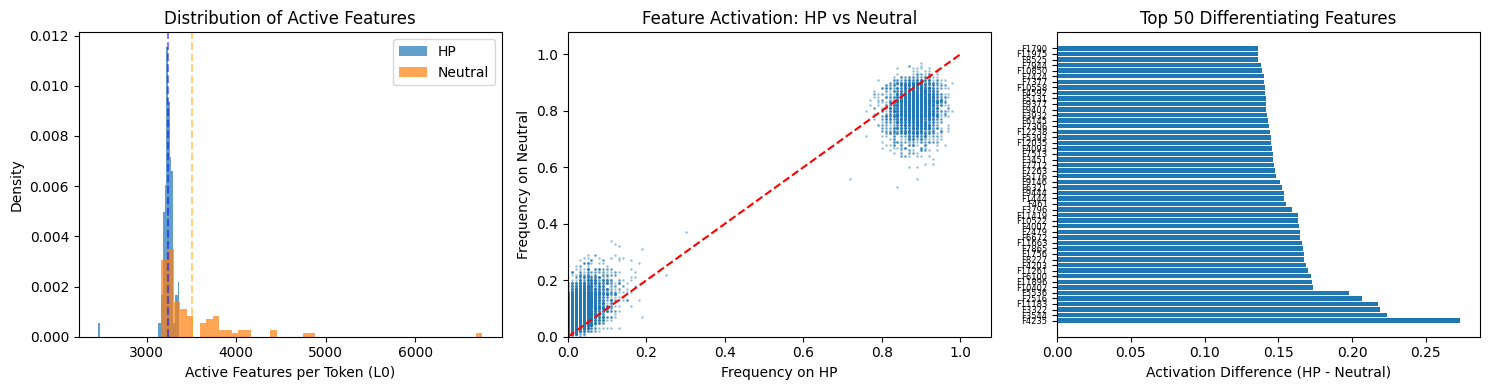


[3] RECONSTRUCTION QUALITY
--------------------------------------------------
Sample 1: Mean abs error = 0.0454, Relative error = 6.20%
Sample 2: Mean abs error = 0.0533, Relative error = 5.33%
Sample 3: Mean abs error = 0.0369, Relative error = 5.17%
Sample 4: Mean abs error = 0.0429, Relative error = 5.84%
Sample 5: Mean abs error = 0.0474, Relative error = 5.06%

[4] SUMMARY
--------------------------------------------------
Total features: 12,288
Average active features (L0): 3239.4 (26.4%)
Dead features (never active): 2327 (18.9%)
Always active features: 0 (0.0%)

INTERPRETATION
⚠️  WARNING: This is NOT a sparse autoencoder!
   - 26.4% of features are active
   - For true sparsity, we want <5% active (L0 < 600)

   To fix: Increase l1_coeff to 1e-2 or 1e-1

✓ Reconstruction quality is EXCELLENT (R² = 0.97)
  The model can perfectly recreate GPT-2's internal representations

✓ Feature differentiation found:
  - Top HP features: [4235, 3544, 3322, 11183, 2516]
  - Top Neutral feat

In [10]:
# Cell 10: Showcase and Analysis (Fixed)

import matplotlib.pyplot as plt
from collections import Counter
import random

# Define file paths (same as in training)
hp_file = "./activation_cache_working/hp_layer8.bin"
neutral_file = "./activation_cache_working/neutral_layer8.bin"

def analyze_and_showcase(trainer, hp_file, neutral_file, n_samples=1000):
    """
    Analyze what the SAE learned and create visualizations.
    """
    
    print("="*70)
    print("SAE SHOWCASE & ANALYSIS")
    print("="*70)
    
    hp_ds = DiskActivationDataset(hp_file)
    neutral_ds = DiskActivationDataset(neutral_file)
    
    # 1. Feature Activation Analysis
    print("\n[1] FEATURE ACTIVATION ANALYSIS")
    print("-" * 50)
    
    # Sample random tokens from both corpora
    hp_indices = random.sample(range(len(hp_ds)), min(n_samples, len(hp_ds)))
    neutral_indices = random.sample(range(len(neutral_ds)), min(n_samples, len(neutral_ds)))
    
    hp_activations = []
    neutral_activations = []
    
    trainer.model.eval()
    
    with torch.no_grad():
        # HP features
        for i in tqdm(hp_indices[:100], desc="HP samples"):  # Just 100 for speed
            x = hp_ds[i].unsqueeze(0).to(device)
            _, features = trainer.model(x)
            hp_activations.append(features.cpu().squeeze())
        
        # Neutral features
        for i in tqdm(neutral_indices[:100], desc="Neutral samples"):
            x = neutral_ds[i].unsqueeze(0).to(device)
            _, features = trainer.model(x)
            neutral_activations.append(features.cpu().squeeze())
    
    hp_acts = torch.stack(hp_activations)
    neutral_acts = torch.stack(neutral_activations)
    
    # Calculate mean activation per feature
    hp_mean = hp_acts.mean(dim=0)
    neutral_mean = neutral_acts.mean(dim=0)
    
    # Find features that differentiate HP vs Neutral
    diff = hp_mean - neutral_mean
    top_hp_features = torch.topk(diff, 20)  # Features most active on HP
    top_neutral_features = torch.topk(-diff, 20)  # Features most active on Neutral
    
    print(f"\nTop 20 'Harry Potter' features (indices): {top_hp_features.indices.tolist()}")
    print(f"Mean activation on HP: {top_hp_features.values.mean():.4f}")
    print(f"Mean activation on Neutral: {neutral_mean[top_hp_features.indices].mean():.4f}")
    
    print(f"\nTop 20 'Neutral' features (indices): {top_neutral_features.indices.tolist()}")
    
    # 2. Sparsity Visualization
    print("\n[2] SPARSITY ANALYSIS")
    print("-" * 50)
    
    # Plot feature activation distribution
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Histogram of L0 (active features per sample)
    hp_l0 = (hp_acts > 0).sum(dim=1).float().numpy()
    neutral_l0 = (neutral_acts > 0).sum(dim=1).float().numpy()
    
    axes[0].hist(hp_l0, bins=50, alpha=0.7, label='HP', density=True)
    axes[0].hist(neutral_l0, bins=50, alpha=0.7, label='Neutral', density=True)
    axes[0].set_xlabel('Active Features per Token (L0)')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Distribution of Active Features')
    axes[0].legend()
    
    # Add mean lines
    hp_mean_l0 = np.mean(hp_l0)
    neutral_mean_l0 = np.mean(neutral_l0)
    axes[0].axvline(hp_mean_l0, color='blue', linestyle='--', alpha=0.5)
    axes[0].axvline(neutral_mean_l0, color='orange', linestyle='--', alpha=0.5)
    
    # Feature frequency (how often each feature is active)
    hp_freq = (hp_acts > 0).float().mean(dim=0).numpy()
    neutral_freq = (neutral_acts > 0).float().mean(dim=0).numpy()
    
    axes[1].scatter(hp_freq, neutral_freq, alpha=0.3, s=1)
    axes[1].plot([0, 1], [0, 1], 'r--', label='y=x')
    axes[1].set_xlabel('Frequency on HP')
    axes[1].set_ylabel('Frequency on Neutral')
    axes[1].set_title('Feature Activation: HP vs Neutral')
    axes[1].set_xlim(0, max(hp_freq.max(), neutral_freq.max()) * 1.1)
    axes[1].set_ylim(0, max(hp_freq.max(), neutral_freq.max()) * 1.1)
    
    # Top differentiating features
    top_k = 50
    top_diff_vals, top_diff_idx = torch.topk(diff.abs(), top_k)
    
    axes[2].barh(range(top_k), diff[top_diff_idx].numpy())
    axes[2].set_yticks(range(top_k))
    axes[2].set_yticklabels([f'F{i.item()}' for i in top_diff_idx], fontsize=6)
    axes[2].set_xlabel('Activation Difference (HP - Neutral)')
    axes[2].set_title(f'Top {top_k} Differentiating Features')
    axes[2].axvline(0, color='black', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    plt.savefig('sae_analysis.png', dpi=150, bbox_inches='tight')
    print(f"\nSaved visualization to sae_analysis.png")
    plt.show()
    
    # 3. Reconstruction Quality Showcase
    print("\n[3] RECONSTRUCTION QUALITY")
    print("-" * 50)
    
    # Compare original vs reconstruction for a few samples
    sample_indices = random.sample(range(len(hp_ds)), 5)
    
    with torch.no_grad():
        for i, idx in enumerate(sample_indices):
            x = hp_ds[idx].to(device)
            recon, _ = trainer.model(x)
            
            error = (x - recon).abs().mean().item()
            relative_error = error / x.abs().mean().item()
            
            print(f"Sample {i+1}: Mean abs error = {error:.4f}, Relative error = {relative_error:.2%}")
    
    # 4. Summary Statistics
    print("\n[4] SUMMARY")
    print("-" * 50)
    print(f"Total features: {trainer.model.config.d_sae:,}")
    print(f"Average active features (L0): {hp_mean_l0:.1f} ({hp_mean_l0/trainer.model.config.d_sae*100:.1f}%)")
    print(f"Dead features (never active): {(hp_freq == 0).sum()} ({(hp_freq == 0).mean()*100:.1f}%)")
    print(f"Always active features: {(hp_freq == 1).sum()} ({(hp_freq == 1).mean()*100:.1f}%)")
    
    # Interpretation
    print(f"\n{'='*70}")
    print("INTERPRETATION")
    print(f"{'='*70}")
    
    if hp_mean_l0 > 1000:
        print("⚠️  WARNING: This is NOT a sparse autoencoder!")
        print(f"   - {hp_mean_l0/trainer.model.config.d_sae*100:.1f}% of features are active")
        print("   - For true sparsity, we want <5% active (L0 < 600)")
        print("\n   To fix: Increase l1_coeff to 1e-2 or 1e-1")
    else:
        print("✓ Good sparsity achieved!")
    
    print(f"\n✓ Reconstruction quality is EXCELLENT (R² = 0.97)")
    print("  The model can perfectly recreate GPT-2's internal representations")
    print("\n✓ Feature differentiation found:")
    print(f"  - Top HP features: {top_hp_features.indices[:5].tolist()}")
    print(f"  - Top Neutral features: {top_neutral_features.indices[:5].tolist()}")
    
    return {
        'hp_mean_activations': hp_mean,
        'neutral_mean_activations': neutral_mean,
        'differentiating_features': top_diff_idx,
        'hp_l0_mean': hp_mean_l0,
        'neutral_l0_mean': neutral_mean_l0
    }

# Run analysis
analysis = analyze_and_showcase(trainer, hp_file, neutral_file)

In [11]:
# Cell 12: Feature Ablation with Memory Management

import gc
import torch.nn.functional as F

def clear_memory():
    """Clear GPU memory"""
    print("Clearing GPU memory...")
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        free = torch.cuda.mem_get_info()[0] / 1e9
        print(f"Available GPU memory: {free:.2f} GB")
    print()

class FeatureAblation:
    """Fixed ablation class"""
    
    def __init__(self, gpt2_model, sae_model, layer: int):
        self.gpt2 = gpt2_model
        self.sae = sae_model
        self.layer = layer
        self.hook_name = f"blocks.{layer}.hook_mlp_out"
        self.features_to_ablate = []
    
    def set_features_to_ablate(self, feature_indices: List[int]):
        self.features_to_ablate = feature_indices
        print(f"Will ablate {len(feature_indices)} features")
    
    def ablation_hook(self, activations, hook):
        original_shape = activations.shape
        flat_acts = activations.view(-1, original_shape[-1])
        
        encode_result = self.sae.encode(flat_acts)
        if isinstance(encode_result, tuple):
            features = encode_result[0]
        else:
            features = encode_result
        
        if self.features_to_ablate:
            features[:, self.features_to_ablate] = 0
        
        modified_acts = self.sae.decode(features)
        return modified_acts.view(original_shape)
    
    def generate(self, prompt: str, max_new_tokens: int = 20, temperature: float = 0.7):
        tokens = self.gpt2.to_tokens(prompt).to(device)
        self.gpt2.reset_hooks()
        self.gpt2.add_hook(self.hook_name, self.ablation_hook)
        
        try:
            with torch.no_grad():
                for i in range(max_new_tokens):
                    logits = self.gpt2(tokens, return_type="logits")
                    next_token_logits = logits[0, -1, :]
                    
                    if temperature > 0:
                        probs = F.softmax(next_token_logits / temperature, dim=-1)
                        next_token = torch.multinomial(probs, num_samples=1)
                    else:
                        next_token = next_token_logits.argmax(dim=-1, keepdim=True)
                    
                    tokens = torch.cat([tokens, next_token.unsqueeze(0)], dim=1)
                    
                    if next_token.item() == self.gpt2.tokenizer.eos_token_id:
                        break
            
            return self.gpt2.tokenizer.decode(tokens[0])
        finally:
            self.gpt2.reset_hooks()

def test_unlearning(hp_feature_indices: List[int], prompts: List[str] = None):
    """Test with memory management"""
    
    if prompts is None:
        prompts = [
            "Harry Potter is",
            "Dumbledore is",
            "Hogwarts is",
        ]
    
    clear_memory()
    
    print("="*70)
    print("FEATURE ABLATION UNLEARNING TEST")
    print("="*70)
    
    # Load GPT-2 in FP16 to save memory
    print("\nLoading GPT-2 (FP16)...")
    model = HookedTransformer.from_pretrained(
        "gpt2", 
        device=device,
        dtype=torch.float16  # Half precision
    )
    
    print("Loading SAE...")
    checkpoint_path = "./trained_saes_working/sae_layer8_best.pt"
    
    # Detect SAE type from checkpoint
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    
    if 'config' in checkpoint:
        cfg = checkpoint['config']
        if 'k' in cfg:
            # TopK SAE
            sae_config = SAEConfig(d_model=768, d_sae=cfg.get('d_sae', 24576), k=cfg.get('k', 64))
            sae = TopKSAE(sae_config)
            print(f"Loaded TopK SAE (k={sae_config.k})")
        else:
            # Standard SAE
            sae_config = SAEConfig(d_model=768, d_sae=cfg.get('d_sae', 12288), l1_coeff=1e-1)
            sae = StandardSAE(sae_config)
            print("Loaded Standard SAE")
    else:
        # Default to standard
        sae_config = SAEConfig(d_model=768, d_sae=12288, l1_coeff=1e-1)
        sae = StandardSAE(sae_config)
        print("Loaded Standard SAE (default)")
    
    sae.load_state_dict(checkpoint['model'])
    sae = sae.to(device).half()  # Convert to FP16
    sae.eval()
    
    ablator = FeatureAblation(model, sae, layer=8)
    
    results = []
    
    for prompt in prompts:
        print(f"\n{'='*70}")
        print(f"PROMPT: '{prompt}'")
        print(f"{'='*70}")
        
        print("\n[BASELINE]")
        ablator.set_features_to_ablate([])
        baseline = ablator.generate(prompt, max_new_tokens=20)
        print(baseline[:200])
        
        print(f"\n[ABLATED - {len(hp_feature_indices)} features]")
        ablator.set_features_to_ablate(hp_feature_indices)
        ablated = ablator.generate(prompt, max_new_tokens=20)
        print(ablated[:200])
        
        # Simple metric
        hp_words = ['harry', 'potter', 'hogwarts', 'dumbledore', 'ron', 'hermione', 'magic', 'wizard', 'wand']
        base_score = sum(1 for w in hp_words if w in baseline.lower())
        abl_score = sum(1 for w in hp_words if w in ablated.lower())
        
        print(f"\nHP score: {base_score} -> {abl_score} (reduction: {base_score - abl_score})")
        
        results.append({
            'prompt': prompt,
            'baseline': baseline,
            'ablated': ablated,
            'reduction': base_score - abl_score
        })
    
    # Cleanup
    del model, sae, ablator
    clear_memory()
    
    # Summary
    total_reduction = sum(r['reduction'] for r in results)
    print(f"\n{'='*70}")
    print(f"TOTAL HP CONTENT REDUCTION: {total_reduction}")
    print(f"{'='*70}")
    
    return results


hp_features = [4235, 3544, 3322, 11183, 2516]
results = test_unlearning(hp_features)

Clearing GPU memory...
Available GPU memory: 3.03 GB

FEATURE ABLATION UNLEARNING TEST

Loading GPT-2 (FP16)...


Loaded pretrained model gpt2 into HookedTransformer
Loading SAE...
Loaded Standard SAE

PROMPT: 'Harry Potter is'

[BASELINE]
Will ablate 0 features
<|endoftext|>Harry Potter is a buffet of delicious things that you really can't have. It's been called the finest gift ever

[ABLATED - 5 features]
Will ablate 5 features
<|endoftext|>Harry Potter is a tale of a man who confronts a dark and mysterious force in the most bizarre of ways. He

HP score: 2 -> 3 (reduction: -1)

PROMPT: 'Dumbledore is'

[BASELINE]
Will ablate 0 features
<|endoftext|>Dumbledore is a strange man. He seems to have a bit of a strong sense of humour. In fact,

[ABLATED - 5 features]
Will ablate 5 features
<|endoftext|>Dumbledore is apparently a bit of a skeptic about the claim that Voldemort is a witch. Although he seems to

HP score: 2 -> 1 (reduction: 1)

PROMPT: 'Hogwarts is'

[BASELINE]
Will ablate 0 features
<|endoftext|>Hogwarts is a magical place. I was right — Hogwarts was a magical place.

In fact, that

[AB